In [1]:
import numpy as np # Para el uso de algebra lineal
import matplotlib.pyplot as plt #Creación de gráficos y curva de aprendizaje
import pandas as pd #Carga y manipulación del dataset (CSV)
import copy # Para crear copias de los parámetros
import seaborn as sns # Visualización estadística de los datos

In [2]:
df = pd.read_csv("data.csv") # Aqui muestro la tabla original completa de la empresas de Taiwan
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [3]:
df.info()  #Usamos esta funcion para saber las dimensiones de la tabla (el numero de columnas y filas) y analizar el posible sobre-ajuste

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [4]:
df.columns = df.columns.str.strip() #Usamos este codigo para poder quitar las separaciones de inicio y final que hay en el texto de cada columna
print(df.columns.tolist())

['Bankrupt?', 'ROA(C) before interest and depreciation before interest', 'ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 'Operating Gross Margin', 'Realized Sales Gross Margin', 'Operating Profit Rate', 'Pre-tax net Interest Rate', 'After-tax net Interest Rate', 'Non-industry income and expenditure/revenue', 'Continuous interest rate (after tax)', 'Operating Expense Rate', 'Research and development expense rate', 'Cash flow rate', 'Interest-bearing debt interest rate', 'Tax rate (A)', 'Net Value Per Share (B)', 'Net Value Per Share (A)', 'Net Value Per Share (C)', 'Persistent EPS in the Last Four Seasons', 'Cash Flow Per Share', 'Revenue Per Share (Yuan ¥)', 'Operating Profit Per Share (Yuan ¥)', 'Per Share Net profit before tax (Yuan ¥)', 'Realized Sales Gross Profit Growth Rate', 'Operating Profit Growth Rate', 'After-tax Net Profit Growth Rate', 'Regular Net Profit Growth Rate', 'Continuous Net Profit Growth Rate', 'Total Asset Growth R

In [5]:
df['ROA_global'] = (df['ROA(C) before interest and depreciation before interest'] + df['ROA(A) before interest and % after tax'] + df['ROA(B) before interest and depreciation after tax']) / 3
df['Margen_operativo'] = (df['Operating Profit Rate'] + df['Pre-tax net Interest Rate'] + df['After-tax net Interest Rate']) / 3
df['Endeudamiento'] = (df['Total debt/Total net worth'] + df['Debt ratio %'] + df['Liability to Equity']) / 3
df['Liquidez'] = (df['Quick Assets/Total Assets'] + df['Current Assets/Total Assets']) / df['Current Liability to Assets']
df['CashFlow'] = (df['Cash Flow to Total Assets'] + df['Cash Flow to Liability'] + df['CFO to Assets']) / 3

#Selección de columnas finales
df = df[['ROA_global', 'Margen_operativo', 'Endeudamiento', 'Liquidez', 'CashFlow', 'Bankrupt?']] #Esto es la tabla modificada con caracteristicas creadas por mi usando ingenieria de funciones para obtener caracteristicas que determinan si una empresa estara en bancarrota o no y aparte hago reduccion drastica de el sobre-ajuste

#LIMPIEZA
# 1. Convertimos infinitos en NaN (para que dropna los reconozca)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Eliminamos la fila de la empresa que tenga el dato faltante (como la fila 2492)
df.dropna(subset=['ROA_global', 'Margen_operativo', 'Endeudamiento', 'Liquidez', 'CashFlow'], inplace=True)

# Guardamos el archivo ya limpio
df.to_csv('mi_archivo_modificado.csv', index=False)
df.head()

,ROA_global,Margen_operativo,Endeudamiento,Liquidez,CashFlow,Bankrupt?
0,0.400244,0.868222,0.173015,2.425631,0.538849,1
1,0.506412,0.868542,0.155842,5.436090,0.555734,1
2,0.465795,0.867883,0.172984,9.606629,0.546836,1
3,0.436281,0.868211,0.147586,3.924336,0.543887,1
4,0.508584,0.868548,0.130057,5.614691,0.551751,1


In [6]:
#Aqui selecciono las columnas de mi interes para el tema de reescalamiento de datos para optimizar mejor el modelo de IA
columnas_de_interes = ['ROA_global', 'Margen_operativo', 'Endeudamiento', 'Liquidez', 'CashFlow' ]

#Para mayor facilidad lo convertimos de dataframe a una matriz
X = df[columnas_de_interes].values
y = df['Bankrupt?'].values

#Aqui calculamos las medias y desviaciones
x_mean = np.mean(X, axis=0)
x_std = np.std(X, axis=0)

#Aqui usamos este codigo para evitar obtener una desviacion igual a 0 y obtener un error
x_std_copy = np.copy(x_std)
x_std_copy[x_std_copy == 0] = 1

x_escalados = (X-x_mean) / x_std_copy

#Aqui de matriz lo convertimos a dataframe
df[columnas_de_interes] = x_escalados

X_train = x_escalados
y_train = y

# Hacemos la Verificacion correspondiente
print(f"Empresas restantes en el estudio: {len(df)}") # Debe decir 6818 ya que una fila la hemos eliminado por estar vacia
print("Estadísticas finales (Media debe ser casi 0 y Std casi 1):")
print(df[columnas_de_interes].describe().loc[['mean', 'std']])

print(x_mean)
print(x_std)

df.head()

Empresas restantes en el estudio: 6818
Estadísticas finales (Media debe ser casi 0 y Std casi 1):
        ROA_global  Margen_operativo  Endeudamiento      Liquidez  \
mean -6.336315e-16      5.655266e-15  -7.295100e-18 -2.918040e-17   
std   1.000073e+00      1.000073e+00   1.000073e+00  1.000073e+00   

          CashFlow  
mean  3.918511e-16  
std   1.000073e+00  
[5.39144444e-01 8.68344588e-01 1.44915433e+06 1.44307631e+01
 5.68341424e-01]
[6.17905704e-02 1.28103187e-02 5.61036133e+07 2.04822519e+01
 3.52473881e-02]


,ROA_global,Margen_operativo,Endeudamiento,Liquidez,CashFlow,Bankrupt?
0,-2.247915,-0.009577,-0.02583,-0.586124,-0.836732,1
1,-0.529737,0.015434,-0.02583,-0.439145,-0.357681,1
2,-1.187065,-0.036052,-0.02583,-0.235528,-0.610118,1
3,-1.664716,-0.010446,-0.02583,-0.512953,-0.693782,1
4,-0.494580,0.015851,-0.02583,-0.430425,-0.470677,1


In [7]:
#Aqui iniciamos con el modelo de regresion logistica pero regularizado para abordar todo tipo de sobre-ajuste

#funcion sigmoidea
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#aqui haremos la estructura para obtener las derivadas parciales de la gradiente regularizada
def derivada_parcial_gradientes_regularizado(X, y, w, b, factor_lambda):
    m,n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.
    for i in range(m):
        z_wb = 0
        for j in range(n):
            z_wb += X[i,j] * w[j]
        z_wb += b
        f_wb = sigmoid(z_wb)

        dj_db_i = f_wb - y[i]
        dj_db += dj_db_i

        for j in range(n):
            dj_dw[j] = dj_dw[j] + dj_db_i * X[i,j]

    dj_dw = ((1 / m) * dj_dw)
    dj_db = ((1 / m) * dj_db)

    for j in range(n):
        dj_dw[j] = dj_dw[j] + ((factor_lambda / m) * w[j])
    
    return dj_dw, dj_db

#Aqui haremos la estructura de descenso gradual regularizado usando la anterior estructura de derivadas parciales
def descenso_gradual_regularizado(X_train, y_train, w, b, alpha, factor_lambda):
    m, n = X_train.shape
    
    # 1. Calculamos las derivadas (gradientes)
    dj_dw, dj_db = derivada_parcial_gradientes_regularizado(X_train, y_train, w, b, factor_lambda)
    
    # 2. Haremos una actualizacion vectorial 
    # Ya que cuando usamos en vectorial restamos todo el vector de golpe.
    # Esto asegura que los pesos 'w' cambien simultáneamente.
    w = w - (alpha * dj_dw)
    b = b - (alpha * dj_db)

    return w, b

#Aqui hago la estructura del costo de la logistica
def costo_RegresionLogistica_regularizado(X, y, w, b, factor_lambda):
    m,n = X.shape
    costo = 0
    epsilon = 1e-15  #Aqui pongo un parche de seguridad
    for i in range(m):
        z_wb = 0
        for j in range(n):
            z_wb += X[i,j] * w[j]
        z_wb += b
        f_wb = sigmoid(z_wb)

        f_wb = np.clip(f_wb, epsilon, 1 - epsilon) #usamos esta funcion para poder evitar que haya casos como log(0) que ocasionaria error en el Modelo

        if y[i] == 1:
            costo += np.log(f_wb)
        else:
            costo += np.log(1 - f_wb)
    
    total_costo = (-1 / m) * costo
    for j in range(n):
        total_costo = total_costo + ((factor_lambda / (2 * m)) * ((w[j])**2))

    return total_costo

#Aqui la estructura del calculo de la regresion logistica para la clasificacion
def regresion_logistica(X, w, b):
    m,n = X.shape
    costo = 0
    pi = np.zeros(m)
    for i in range(m):
        z_wb = 0
        for j in range(n):
            z_wb += X[i,j] * w[j]
        z_wb += b
        f_wb = sigmoid(z_wb)
        if f_wb >= 0.02:
            pi[i] = 1
        else:
            pi[i] = 0
    
    return pi

#Estructura para la curva de aprendizaje 
def plot_mis_graficas(cost_history):
    plt.figure(figsize=(15, 6))
    
    eje_x = [i * 100 for i in range(len(cost_history))]
    
    plt.plot(eje_x, cost_history, color='blue', lw=2)
    
    # Ponemos marcas cada 100 iteraciones
    plt.xticks(eje_x, rotation=90, fontsize=8)
    
    plt.title("Curva de Aprendizaje - Costo cada 100 iteraciones")
    plt.xlabel("Iteración")
    plt.ylabel("Costo")
    
    # Cuadrícula simple
    plt.grid(True, linestyle=':') 
    
    plt.tight_layout()
    plt.show()

def auditoria_express(datos_empresa, w, b):
        
        # Usamos la lógica de regresion_logistica para obtener 0 o 1
        # Redimensionamos los datos por si solo en el caso alguien ponga una lista
        datos_empresa = np.array(datos_empresa).reshape(1, -1)

        #Calculamos el valor Z y la probabilidad (f_wb)
        #Usamos np.dot para multiplicar los pesos por los datos de la empresa
        z = np.dot(datos_empresa, w) + b
        probabilidad = sigmoid(z)[0]
    
        prediccion = regresion_logistica(datos_empresa, w, b)

        print("--- RESULTADO DE LA AUDITORÍA ---")

        # Imprimimos la probabilidad para que sepamos qué está pasando internamente
        print(f"Probabilidad de quiebra calculada por la IA: {probabilidad:.6%}")

        if prediccion[0] == 1:
            return "SÍ, la empresa entrará en bancarrota. (Riesgo Alto)"
        else:
            return "NO, la empresa se mantendrá estable. (Riesgo Bajo)"
        
def conversion(datos):
    
    # Aseguramos que 'datos' sea un array para que la resta funcione bien
    datos = np.array(datos)

    datos_escalados = (datos - x_mean) / x_std_copy

    return datos_escalados

    

Iniciando entrenamiento...
Iteración     0: Costo 0.671258
Iteración   100: Costo 0.179942
Iteración   200: Costo 0.139691
Iteración   300: Costo 0.127114
Iteración   400: Costo 0.121267
Iteración   500: Costo 0.117980
Iteración   600: Costo 0.115903
Iteración   700: Costo 0.114480
Iteración   800: Costo 0.113444
Iteración   900: Costo 0.112651
Iteración  1000: Costo 0.112020
Iteración  1100: Costo 0.111501
Iteración  1200: Costo 0.111062
Iteración  1300: Costo 0.110683
Iteración  1400: Costo 0.110351
Iteración  1500: Costo 0.110054
Iteración  1600: Costo 0.109785
Iteración  1700: Costo 0.109541
Iteración  1800: Costo 0.109316
Iteración  1900: Costo 0.109108
Iteración  2000: Costo 0.108914
Iteración  2100: Costo 0.108733
Iteración  2200: Costo 0.108563
Iteración  2300: Costo 0.108403
Iteración  2400: Costo 0.108251
Iteración  2500: Costo 0.108107
Iteración  2600: Costo 0.107971
Iteración  2700: Costo 0.107841
Iteración  2800: Costo 0.107718
Iteración  2900: Costo 0.107600
Iteración  30

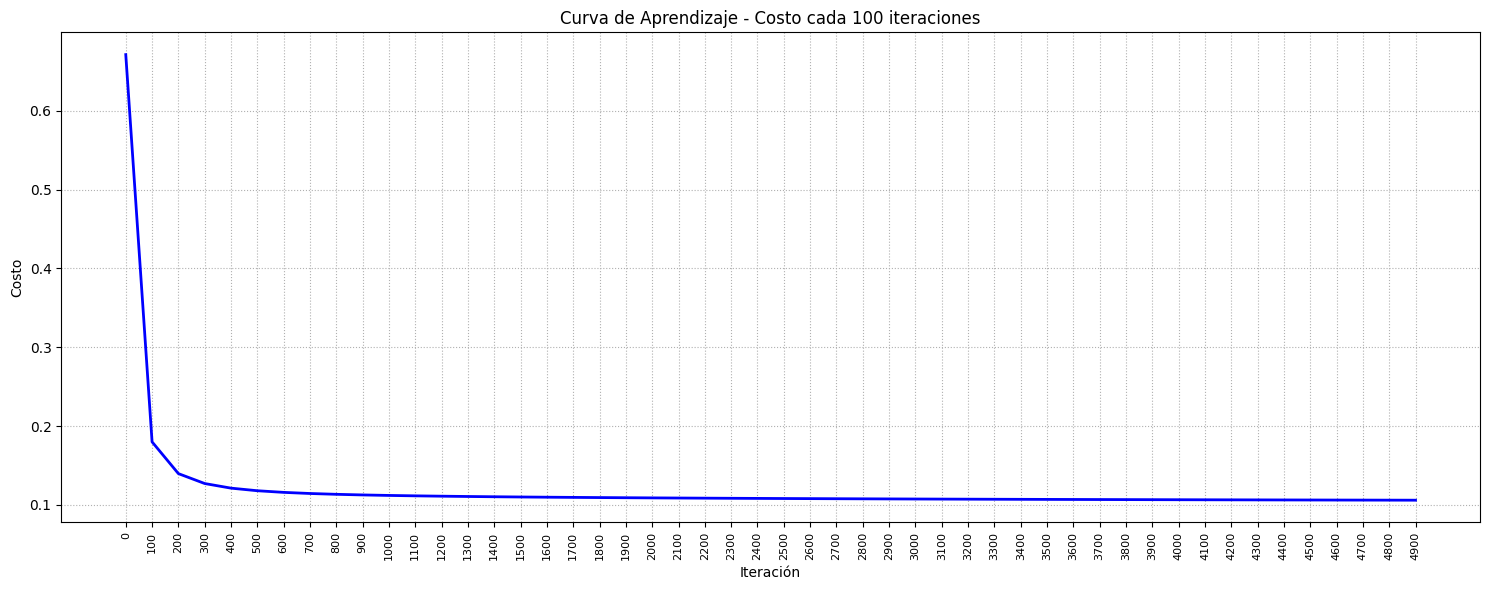

In [8]:
w_final = np.zeros(X_train.shape[1])
b_final = 0.0
X_train = x_escalados
y_train = y
alpha = 0.1
lambda_reg = 0.001
iteraciones = 5000
#Inicializar como diccionario
hist = {"cost": []}

print("Iniciando entrenamiento...")

for i in range(iteraciones):
    # llamamos a la función de descenso gradual
    w_final, b_final = descenso_gradual_regularizado(X_train, y_train, w_final, b_final, alpha, lambda_reg)
    
    # Guardarmos e imprimimos cada 100 iteraciones
    if i % 100 == 0:
        costo_actual = costo_RegresionLogistica_regularizado(X_train, y_train, w_final, b_final, lambda_reg)
        hist["cost"].append(costo_actual)
        
        # Esto imprimirá en la consola: Iteración 0, 100, 200, etc.
        print(f"Iteración {i:5}: Costo {costo_actual:.6f}")

print("¡Entrenamiento finalizado!")

# Llamada a la función usando el diccionario 'hist' que se llenara en el entrenamiento
plot_mis_graficas(hist["cost"])

In [14]:
# --- EJEMPLO DE PRUEBA ---
# Introducimos aquí los valores de la empresa (deben ser si o si 5 datos por empresa ya que el modelo evalua 5 factores)
# [ROA, Margen, Liquidez, Endeudamiento, CashFlow]

# 1. Definimos los datos (sin escalar)
empresa_sana = [0.65, 0.25, 0.15, 0.85, 0.70]
empresa_en_riesgo = [0.10, 0.05, 0.85, 0.10, 0.02]
empresa_taiwan_quiebra = [0.01, 0.01, 0.01, 0.99, 0.01]

# 2. Pasamos por la función de conversión (usando las medias de Taiwán)
sana_escalada = conversion(empresa_sana)
riesgo_escalada = conversion(empresa_en_riesgo)
datos_listos = conversion(empresa_taiwan_quiebra)

# 3. Metemos los datos escalados a la auditoría
print("Prueba Empresa Sana:")
print(auditoria_express(sana_escalada, w_final, b_final))

print("\nPrueba Empresa en Riesgo:")
print(auditoria_express(riesgo_escalada, w_final, b_final))

print("Prueba Empresa en bancarrota:")
print(auditoria_express(datos_listos, w_final, b_final))

Prueba Empresa Sana:
--- RESULTADO DE LA AUDITORÍA ---
Probabilidad de quiebra calculada por la IA: 0.009116%
NO, la empresa se mantendrá estable. (Riesgo Bajo)

Prueba Empresa en Riesgo:
--- RESULTADO DE LA AUDITORÍA ---
Probabilidad de quiebra calculada por la IA: 22.082075%
SÍ, la empresa entrará en bancarrota. (Riesgo Alto)
Prueba Empresa en bancarrota:
--- RESULTADO DE LA AUDITORÍA ---
Probabilidad de quiebra calculada por la IA: 47.435267%
SÍ, la empresa entrará en bancarrota. (Riesgo Alto)
